In [1]:
# Для импорта требуются пакеты numpy и cupy
import cupy as cp
import numpy as np
import compton as cmp # модуль для рассчётов

# Команда для jupyter для подключения интерактивных графиков для matplotlib (не обязательно)
%matplotlib widget 
import matplotlib.pyplot as plt # для построения графиков

/home/als/miniforge3/envs/core/lib/python3.14/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
chargeNC = 10.0                          # Полный заряд пучка в нКл
gamma_0 = 2000.                          # Средний Лоренц-фактор электронов

sigma_ex = 10e-4                         # Размер пучка электронов по оси x в см (полуширина по уровню 1/e плотности)
sigma_ey = 10e-4                         # Размер пучка электронов по оси y в см
electron_duration = 10e-12               # Длительность пучка электронов в с

sigma_ez = electron_duration * (3.0e10)  # Размер пучка электронов по оси z в см
norm_emit_x = 1.0e-4                     # Нормализованный эмиттанс электронов по оси х в см * рад
norm_emit_y = 0.01*1.0e-4                     # Нормализованный эмиттанс электронов по оси y в см * рад
emit_x = norm_emit_x / gamma_0           # Эмиттанс электронов по оси х
emit_y = norm_emit_y / gamma_0           # Эмиттанс электронов по оси y

compton = cmp.Compton() # Объект, который хранит параметры взаимодействия
compton.set_electron_parameters(chargeNC = chargeNC, emit_x = emit_x, emit_y = emit_y, sigma_ex = sigma_ex, sigma_ey = sigma_ey, sigma_ez = sigma_ez)

w_l = 20            # Энергия лазерного пучка в Дж
lambda_l = 1030e-7  # Длина волны лазера в см
beta_ff = 0.0       # Скорость движения фокуса (1.0 соответствует движению вместе с электронами)
compton.set_laser_parameters(WL = w_l, lambda_l = lambda_l, sigma_lr0 = sigma_ex, sigma_lz = sigma_ez, beta_ff = 0.0)

compton.set_foci_displacement(0.0, 0.0, 0.0) # Смещение фокуса электронов относительно фокуса лазера

In [3]:
fth = compton.calculate_intersection(theta_num=64, particles_amount = 4096, debug_idx = 495)

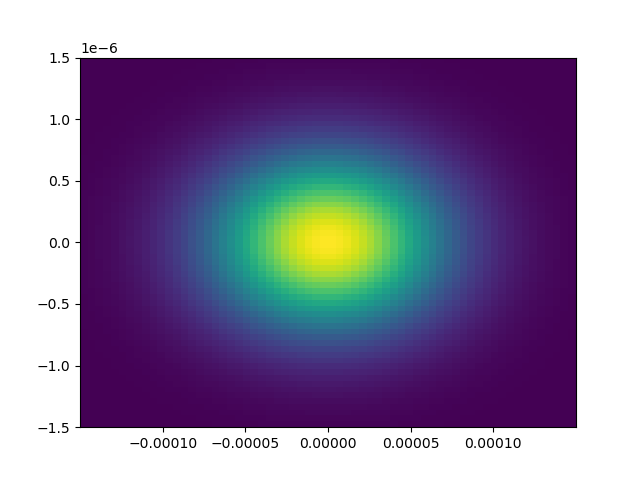

In [4]:
fig,ax=plt.subplots()
ax.imshow(compton.intersection.T.get(),extent=compton.theta_extent)
ax.set_aspect('auto')

In [5]:
sigma_gamma = 0.5 / 100 * gamma_0
thx = cp.linspace(0.0,1.0/gamma_0,127,dtype=cp.float32)
th_zero = cp.array([0.0],dtype=cp.float32)
ss = (cp.linspace(0.8,1.1,256)*gamma_0**2).astype(cp.float32)
spec_kwargs = dict(gamma_0 = gamma_0, sigma_gamma = sigma_gamma, phi_pol = 0*np.pi/2, weight_bias = 0.05, samples_per_point = 32)
spec_x, dt, arcs, n_arcs = compton.calculate_angular_spectrum(ss, thx, th_zero, **spec_kwargs)
spec_y, dt, arcs, n_arcs = compton.calculate_angular_spectrum(ss, th_zero, thx, **spec_kwargs)
ss_tot = (cp.linspace(0.0,1.1,512)*gamma_0**2).astype(cp.float32)
spec_tot = compton.calculate_spectrum(ss_tot, gamma_0, sigma_gamma)
print(f"Total yield: {compton.calculate_total():.2e} photons")

Total yield: 7.30e+10 photons


Text(0.5, 0, 'E, MeV')

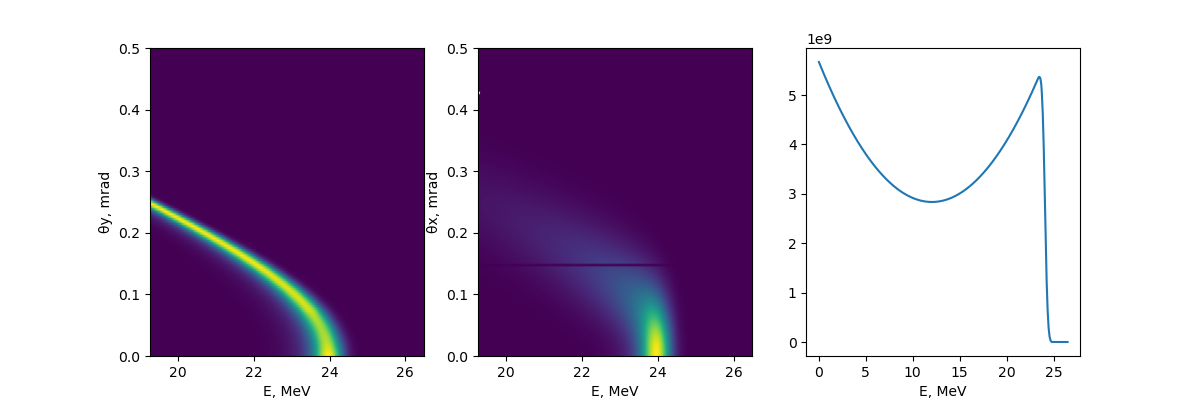

In [7]:
fig,axes=plt.subplots(1,3,figsize=(12,4))
s_scale = 5 * compton.Wph
for i, spec in enumerate([spec_y, spec_x]):
    ax=axes[i]
    ax.imshow(spec.sum(axis=i),origin='lower', extent=[ss[0].get()*s_scale,ss[-1].get()*s_scale,thx[0].get()*1e3,thx[-1].get()*1e3])
    ax.set_aspect('auto')
    ax.set_xlabel("E, MeV")
    ax.set_ylabel(f"θ{'yx'[i]}, mrad")

ax=axes[2]
ax.plot(ss_tot.get()*s_scale, spec_tot)
ax.set_xlabel("E, MeV")